# Proyek Akhir: Menyelesaikan Permasalahan Institusi Pendidikan - Jaya Jaya Institut

- Nama: Putera Nami Shiddieqy
- Email: puteranami1150@gmail.com
- Id Dicoding: puteranami

## Persiapan

### Menyiapkan library yang dibutuhkan

Pada tahap ini, kita mengimpor seluruh library yang dibutuhkan untuk analisis data, visualisasi, preprocessing, dan pemodelan machine learning. Library utama meliputi:
- **pandas & numpy**: Manipulasi dan analisis data
- **matplotlib & seaborn**: Visualisasi data
- **scikit-learn**: Preprocessing, modeling, dan evaluasi
- **imbalanced-learn (SMOTE)**: Menangani class imbalance
- **joblib**: Menyimpan model dan preprocessor

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
from imblearn.over_sampling import SMOTE
import joblib
import os
import warnings
warnings.filterwarnings('ignore')

# Set visual style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

### Menyiapkan data yang akan digunakan

Dataset berasal dari `data/data.csv`. Dataset ini berisi data mahasiswa yang terdaftar di berbagai program studi sarjana di Jaya Jaya Institut.
Data mencakup informasi yang diketahui saat pendaftaran mahasiswa (jalur akademik, demografi, dan faktor sosial-ekonomi) serta performa akademik di akhir semester 1 dan semester 2.

**Catatan:** Dataset menggunakan separator titik koma (`;`).

In [2]:
# Load data dengan separator titik koma
df = pd.read_csv('data/data.csv', sep=';')
df.head()

,Marital_status,Application_mode,Application_order,Course,Daytime_evening_attendance,Previous_qualification,Previous_qualification_grade,Nacionality,Mothers_qualification,Fathers_qualification,...,Curricular_units_2nd_sem_credited,Curricular_units_2nd_sem_enrolled,Curricular_units_2nd_sem_evaluations,Curricular_units_2nd_sem_approved,Curricular_units_2nd_sem_grade,Curricular_units_2nd_sem_without_evaluations,Unemployment_rate,Inflation_rate,GDP,Status
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


## Data Understanding

Pada tahap ini, kita akan memahami karakteristik data secara menyeluruh:
- Memeriksa shape data (jumlah baris dan kolom)
- Mengidentifikasi missing values
- Melihat distribusi target (Status: Dropout, Graduate, Enrolled)
- Meninjau informasi tipe data dan statistik deskriptif

In [3]:
print('Shape data:', df.shape)
print('\nNama kolom:')
print(df.columns.tolist())
print('\nMissing values per kolom:')
missing = df.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else 'Tidak ada missing values!')
print('\nDistribusi Target (Status):')
print(df['Status'].value_counts())
print('\nInfo Data:')
df.info()
print('\nStatistik Deskriptif:')
df.describe()

Shape data: (4424, 37)

Nama kolom:
['Marital_status', 'Application_mode', 'Application_order', 'Course', 'Daytime_evening_attendance', 'Previous_qualification', 'Previous_qualification_grade', 'Nacionality', 'Mothers_qualification', 'Fathers_qualification', 'Mothers_occupation', 'Fathers_occupation', 'Admission_grade', 'Displaced', 'Educational_special_needs', 'Debtor', 'Tuition_fees_up_to_date', 'Gender', 'Scholarship_holder', 'Age_at_enrollment', 'International', 'Curricular_units_1st_sem_credited', 'Curricular_units_1st_sem_enrolled', 'Curricular_units_1st_sem_evaluations', 'Curricular_units_1st_sem_approved', 'Curricular_units_1st_sem_grade', 'Curricular_units_1st_sem_without_evaluations', 'Curricular_units_2nd_sem_credited', 'Curricular_units_2nd_sem_enrolled', 'Curricular_units_2nd_sem_evaluations', 'Curricular_units_2nd_sem_approved', 'Curricular_units_2nd_sem_grade', 'Curricular_units_2nd_sem_without_evaluations', 'Unemployment_rate', 'Inflation_rate', 'GDP', 'Status']

Missin

,Marital_status,Application_mode,Application_order,Course,Daytime_evening_attendance,Previous_qualification,Previous_qualification_grade,Nacionality,Mothers_qualification,Fathers_qualification,...,Curricular_units_1st_sem_without_evaluations,Curricular_units_2nd_sem_credited,Curricular_units_2nd_sem_enrolled,Curricular_units_2nd_sem_evaluations,Curricular_units_2nd_sem_approved,Curricular_units_2nd_sem_grade,Curricular_units_2nd_sem_without_evaluations,Unemployment_rate,Inflation_rate,GDP
count,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,...,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000
mean,1.178571,18.669078,1.727848,8856.642631,0.890823,4.577758,132.613314,1.873192,19.561935,22.275316,...,0.137658,0.541817,6.232143,8.063291,4.435805,10.230206,0.150316,11.566139,1.228029,0.001969
std,0.605747,17.484682,1.313793,2063.566416,0.311897,10.216592,13.188332,6.914514,15.603186,15.343108,...,0.690880,1.918546,2.195951,3.947951,3.014764,5.210808,0.753774,2.663850,1.382711,2.269935
min,1.000000,1.000000,0.000000,33.000000,0.000000,1.000000,95.000000,1.000000,1.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,7.600000,-0.800000,-4.060000
25%,1.000000,1.000000,1.000000,9085.000000,1.000000,1.000000,125.000000,1.000000,2.000000,3.000000,...,0.000000,0.000000,5.000000,6.000000,2.000000,10.750000,0.000000,9.400000,0.300000,-1.700000
50%,1.000000,17.000000,1.000000,9238.000000,1.000000,1.000000,133.100000,1.000000,19.000000,19.000000,...,0.000000,0.000000,6.000000,8.000000,5.000000,12.200000,0.000000,11.100000,1.400000,0.320000
75%,1.000000,39.000000,2.000000,9556.000000,1.000000,1.000000,140.000000,1.000000,37.000000,37.000000,...,0.000000,0.000000,7.000000,10.000000,6.000000,13.333333,0.000000,13.900000,2.600000,1.790000
max,6.000000,57.000000,9.000000,9991.000000,1.000000,43.000000,190.000000,109.000000,44.000000,44.000000,...,12.000000,19.000000,23.000000,33.000000,20.000000,18.571429,12.000000,16.200000,3.700000,3.510000


### Exploratory Data Analysis (EDA)

Tahap ini digunakan untuk mengeksplorasi data guna mendapatkan insight mengenai karakteristik data, distribusi, hubungan antar variabel, serta korelasi fitur dengan target `Status`.

EDA dilakukan secara bertahap:
1. **Univariate Analysis** — Menganalisis distribusi variabel secara individual
2. **Bivariate Analysis** — Menganalisis hubungan antara fitur dengan target
3. **Multivariate Analysis** — Menganalisis korelasi antar banyak fitur sekaligus

#### 1. Univariate Analysis

Mari kita lihat distribusi kolom target (`Status`) dan beberapa fitur utama secara individual.

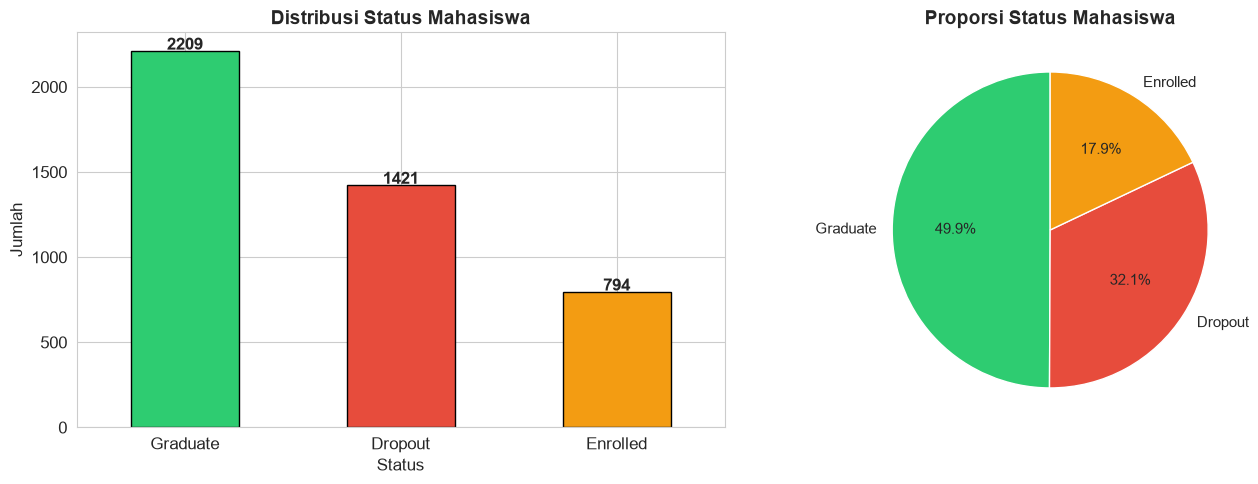


Total mahasiswa: 4424
Dropout: 1421 (32.1%)
Graduate: 2209 (49.9%)
Enrolled: 794 (17.9%)


In [4]:
# Distribusi Target Status
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
status_counts = df['Status'].value_counts()
colors = ['#2ecc71', '#e74c3c', '#f39c12']
status_counts.plot(kind='bar', ax=axes[0], color=colors, edgecolor='black')
axes[0].set_title('Distribusi Status Mahasiswa', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Jumlah')
axes[0].set_xticklabels(status_counts.index, rotation=0)
for i, v in enumerate(status_counts.values):
    axes[0].text(i, v + 10, str(v), ha='center', fontweight='bold')

# Pie chart
status_counts.plot(kind='pie', ax=axes[1], colors=colors, autopct='%1.1f%%',
                   startangle=90, textprops={'fontsize': 11})
axes[1].set_title('Proporsi Status Mahasiswa', fontsize=14, fontweight='bold')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

print(f"\nTotal mahasiswa: {len(df)}")
print(f"Dropout: {status_counts.get('Dropout', 0)} ({status_counts.get('Dropout', 0)/len(df)*100:.1f}%)")
print(f"Graduate: {status_counts.get('Graduate', 0)} ({status_counts.get('Graduate', 0)/len(df)*100:.1f}%)")
print(f"Enrolled: {status_counts.get('Enrolled', 0)} ({status_counts.get('Enrolled', 0)/len(df)*100:.1f}%)")

**Insight:** Distribusi target menunjukkan ketidakseimbangan kelas. Kategori *Graduate* mendominasi, sedangkan *Dropout* merupakan kelas yang perlu mendapat perhatian khusus. Kelas *Enrolled* akan di-drop pada tahap preprocessing karena status akhirnya belum diketahui.

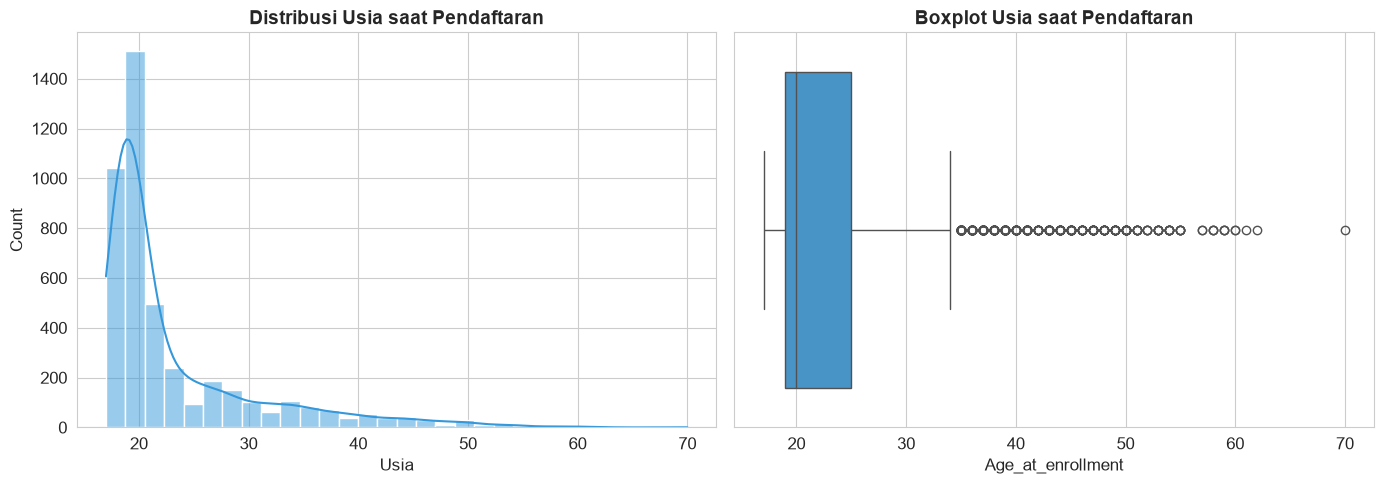

Rata-rata usia: 23.3 tahun
Median usia: 20.0 tahun
Rentang usia: 17 - 70 tahun


In [5]:
# Distribusi Usia saat Pendaftaran (Age at Enrollment)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df['Age_at_enrollment'], bins=30, kde=True, ax=axes[0], color='#3498db')
axes[0].set_title('Distribusi Usia saat Pendaftaran', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Usia')

sns.boxplot(x=df['Age_at_enrollment'], ax=axes[1], color='#3498db')
axes[1].set_title('Boxplot Usia saat Pendaftaran', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"Rata-rata usia: {df['Age_at_enrollment'].mean():.1f} tahun")
print(f"Median usia: {df['Age_at_enrollment'].median():.1f} tahun")
print(f"Rentang usia: {df['Age_at_enrollment'].min()} - {df['Age_at_enrollment'].max()} tahun")

**Insight:** Mayoritas mahasiswa mendaftar pada usia muda (17-20 tahun), namun terdapat distribusi ekor kanan (*right-skewed*) yang menunjukkan adanya mahasiswa dewasa. Mahasiswa dengan usia lebih tua cenderung memiliki tingkat dropout yang lebih tinggi.

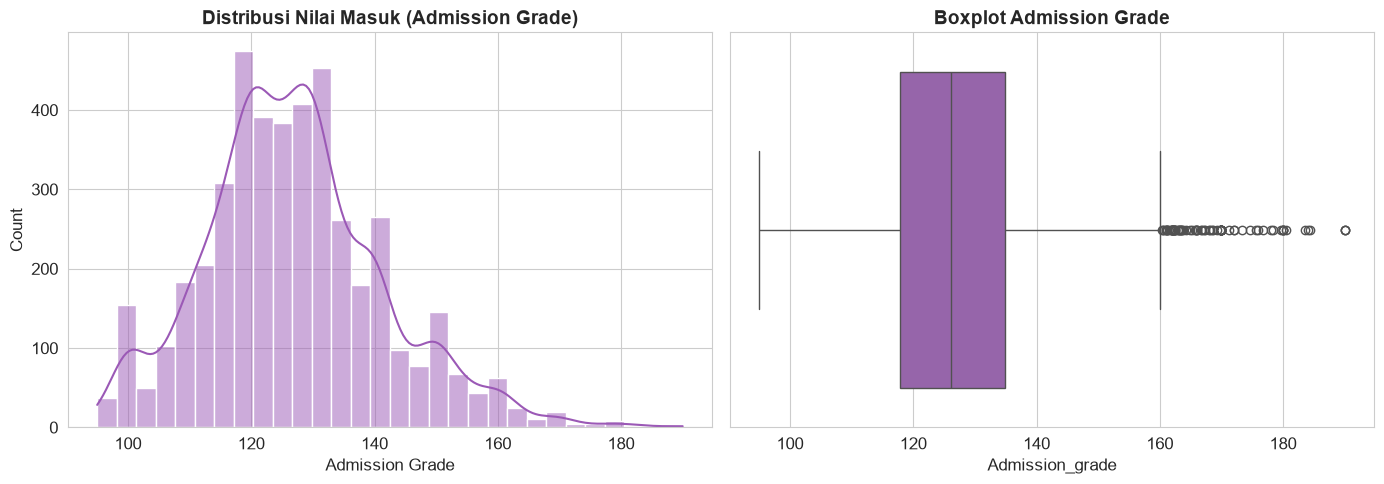

In [6]:
# Distribusi Admission Grade
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df['Admission_grade'], bins=30, kde=True, ax=axes[0], color='#9b59b6')
axes[0].set_title('Distribusi Nilai Masuk (Admission Grade)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Admission Grade')

sns.boxplot(x=df['Admission_grade'], ax=axes[1], color='#9b59b6')
axes[1].set_title('Boxplot Admission Grade', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

#### 2. Bivariate Analysis

Pada tahap ini kita menganalisis hubungan antara masing-masing fitur terhadap target `Status` untuk menemukan pola dan faktor pendorong dropout.

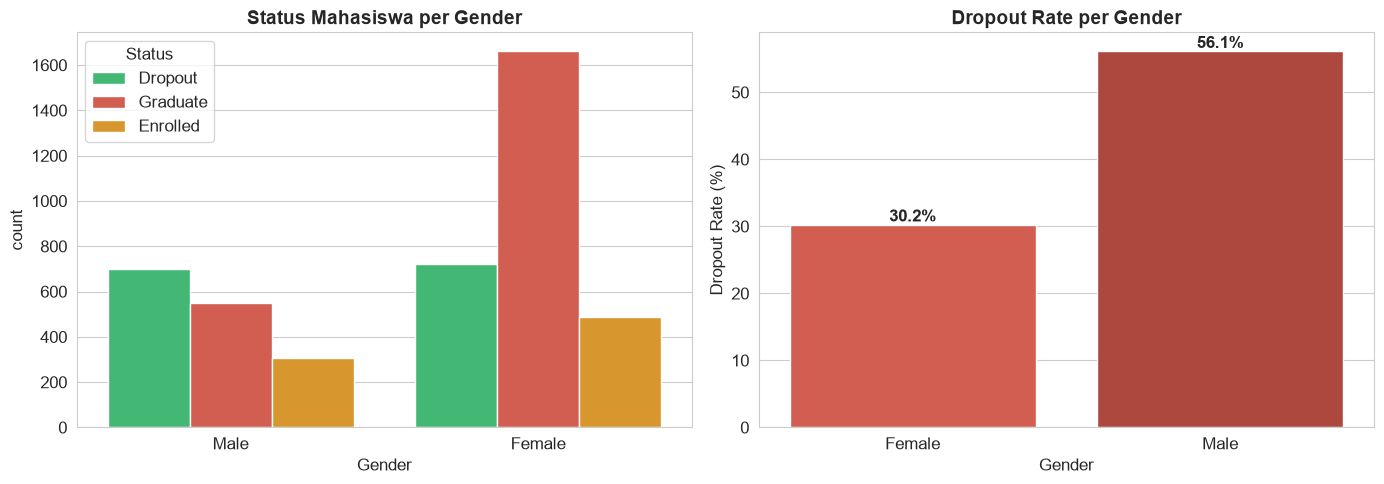

In [7]:
# Dropout Rate per Gender
gender_map = {0: 'Female', 1: 'Male'}
df['Gender_label'] = df['Gender'].map(gender_map)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Count plot
sns.countplot(data=df, x='Gender_label', hue='Status', ax=axes[0],
              palette=['#2ecc71', '#e74c3c', '#f39c12'])
axes[0].set_title('Status Mahasiswa per Gender', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Gender')
axes[0].legend(title='Status')

# Dropout rate per gender
dropout_gender = df[df['Status'] != 'Enrolled'].groupby('Gender_label')['Status'].apply(
    lambda x: (x == 'Dropout').mean() * 100
).reset_index(name='Dropout Rate (%)')

sns.barplot(data=dropout_gender, x='Gender_label', y='Dropout Rate (%)',
            ax=axes[1], palette=['#e74c3c', '#c0392b'])
axes[1].set_title('Dropout Rate per Gender', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Gender')
for i, v in enumerate(dropout_gender['Dropout Rate (%)']):
    axes[1].text(i, v + 0.5, f'{v:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

# Cleanup
df.drop('Gender_label', axis=1, inplace=True)

**Insight:** Terdapat perbedaan dropout rate antara laki-laki dan perempuan. Mahasiswa laki-laki cenderung memiliki dropout rate yang lebih tinggi dibanding perempuan. Hal ini bisa jadi disebabkan oleh faktor sosial-ekonomi atau pilihan karir alternatif.

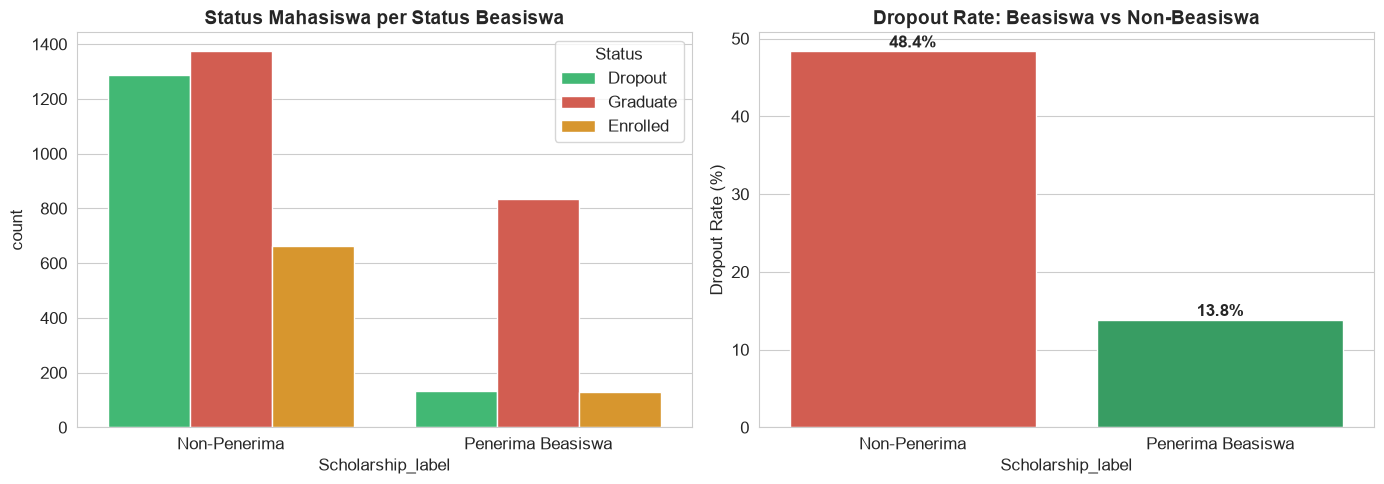

In [8]:
# Dropout Rate berdasarkan Status Beasiswa (Scholarship Holder)
scholarship_map = {0: 'Non-Penerima', 1: 'Penerima Beasiswa'}
df['Scholarship_label'] = df['Scholarship_holder'].map(scholarship_map)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(data=df, x='Scholarship_label', hue='Status', ax=axes[0],
              palette=['#2ecc71', '#e74c3c', '#f39c12'])
axes[0].set_title('Status Mahasiswa per Status Beasiswa', fontsize=14, fontweight='bold')
axes[0].legend(title='Status')

dropout_scholarship = df[df['Status'] != 'Enrolled'].groupby('Scholarship_label')['Status'].apply(
    lambda x: (x == 'Dropout').mean() * 100
).reset_index(name='Dropout Rate (%)')

sns.barplot(data=dropout_scholarship, x='Scholarship_label', y='Dropout Rate (%)',
            ax=axes[1], palette=['#e74c3c', '#27ae60'])
axes[1].set_title('Dropout Rate: Beasiswa vs Non-Beasiswa', fontsize=14, fontweight='bold')
for i, v in enumerate(dropout_scholarship['Dropout Rate (%)']):
    axes[1].text(i, v + 0.5, f'{v:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

df.drop('Scholarship_label', axis=1, inplace=True)

**Insight:** Mahasiswa penerima beasiswa memiliki dropout rate yang jauh lebih rendah dibandingkan non-penerima. Ini menunjukkan bahwa dukungan finansial berperan signifikan dalam retensi mahasiswa.

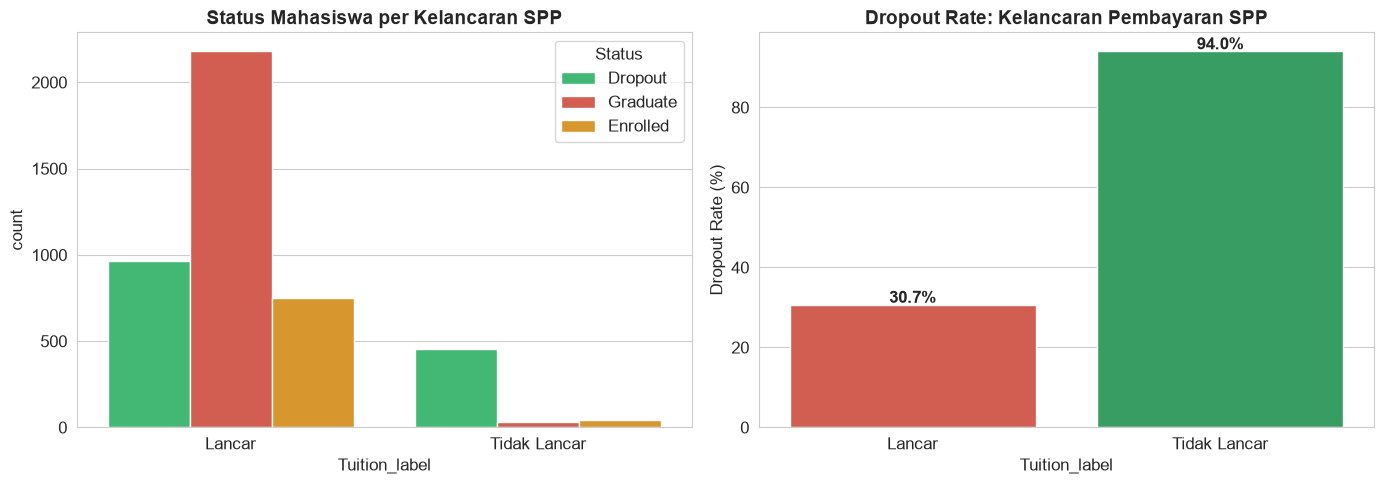

In [9]:
# Dropout Rate berdasarkan Status Pembayaran SPP (Tuition Fees Up to Date)
tuition_map = {0: 'Tidak Lancar', 1: 'Lancar'}
df['Tuition_label'] = df['Tuition_fees_up_to_date'].map(tuition_map)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(data=df, x='Tuition_label', hue='Status', ax=axes[0],
              palette=['#2ecc71', '#e74c3c', '#f39c12'])
axes[0].set_title('Status Mahasiswa per Kelancaran SPP', fontsize=14, fontweight='bold')
axes[0].legend(title='Status')

dropout_tuition = df[df['Status'] != 'Enrolled'].groupby('Tuition_label')['Status'].apply(
    lambda x: (x == 'Dropout').mean() * 100
).reset_index(name='Dropout Rate (%)')

sns.barplot(data=dropout_tuition, x='Tuition_label', y='Dropout Rate (%)',
            ax=axes[1], palette=['#e74c3c', '#27ae60'])
axes[1].set_title('Dropout Rate: Kelancaran Pembayaran SPP', fontsize=14, fontweight='bold')
for i, v in enumerate(dropout_tuition['Dropout Rate (%)']):
    axes[1].text(i, v + 0.5, f'{v:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

df.drop('Tuition_label', axis=1, inplace=True)

**Insight:** Mahasiswa yang tidak lancar membayar SPP memiliki dropout rate yang sangat tinggi. Keterlambatan pembayaran SPP merupakan indikator kuat risiko dropout dan bisa dijadikan *early warning signal* oleh pihak institusi.

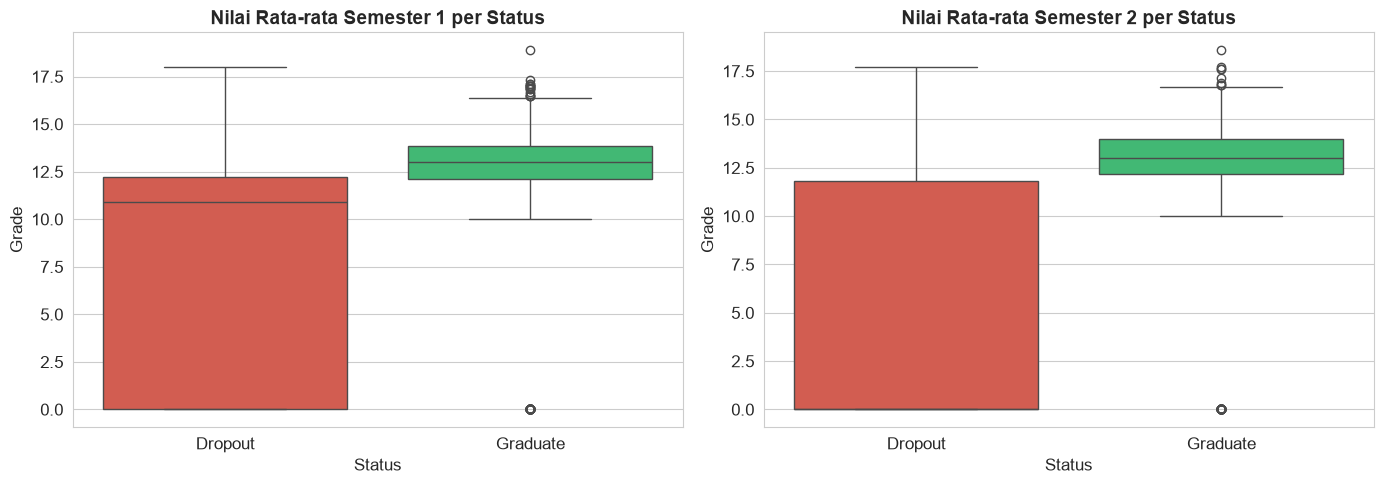

Rata-rata Nilai Semester 1:
Status
Dropout      7.256656
Graduate    12.643655
Name: Curricular_units_1st_sem_grade, dtype: float64

Rata-rata Nilai Semester 2:
Status
Dropout      5.899339
Graduate    12.697276
Name: Curricular_units_2nd_sem_grade, dtype: float64


In [10]:
# Perbandingan Nilai Semester 1 & 2: Dropout vs Graduate
df_filtered = df[df['Status'] != 'Enrolled'].copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=df_filtered, x='Status', y='Curricular_units_1st_sem_grade',
            ax=axes[0], palette=['#e74c3c', '#2ecc71'])
axes[0].set_title('Nilai Rata-rata Semester 1 per Status', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Grade')

sns.boxplot(data=df_filtered, x='Status', y='Curricular_units_2nd_sem_grade',
            ax=axes[1], palette=['#e74c3c', '#2ecc71'])
axes[1].set_title('Nilai Rata-rata Semester 2 per Status', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Grade')

plt.tight_layout()
plt.show()

print('Rata-rata Nilai Semester 1:')
print(df_filtered.groupby('Status')['Curricular_units_1st_sem_grade'].mean())
print('\nRata-rata Nilai Semester 2:')
print(df_filtered.groupby('Status')['Curricular_units_2nd_sem_grade'].mean())

**Insight:** Terdapat perbedaan yang sangat signifikan pada nilai rata-rata semester 1 dan 2 antara mahasiswa yang dropout dan graduate. Mahasiswa dropout memiliki nilai yang jauh lebih rendah, menunjukkan bahwa performa akademik di awal perkuliahan merupakan prediktor kuat untuk dropout.

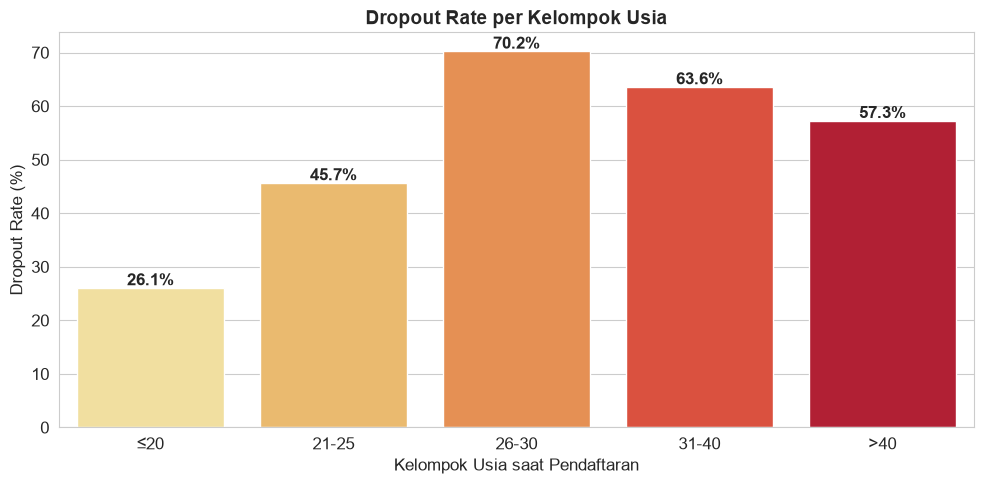

In [11]:
# Dropout Rate berdasarkan Usia (Age Group)
df['Age_group'] = pd.cut(df['Age_at_enrollment'],
                         bins=[0, 20, 25, 30, 40, 100],
                         labels=['≤20', '21-25', '26-30', '31-40', '>40'])

dropout_age = df[df['Status'] != 'Enrolled'].groupby('Age_group', observed=True)['Status'].apply(
    lambda x: (x == 'Dropout').mean() * 100
).reset_index(name='Dropout Rate (%)')

fig, ax = plt.subplots(figsize=(10, 5))
bars = sns.barplot(data=dropout_age, x='Age_group', y='Dropout Rate (%)',
                   ax=ax, palette='YlOrRd')
ax.set_title('Dropout Rate per Kelompok Usia', fontsize=14, fontweight='bold')
ax.set_xlabel('Kelompok Usia saat Pendaftaran')
for i, v in enumerate(dropout_age['Dropout Rate (%)']):
    ax.text(i, v + 0.5, f'{v:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

df.drop('Age_group', axis=1, inplace=True)

**Insight:** Mahasiswa yang mendaftar pada usia yang lebih tua cenderung memiliki dropout rate yang lebih tinggi. Kelompok usia >30 tahun menunjukkan risiko dropout tertinggi, kemungkinan karena tanggung jawab pekerjaan atau keluarga yang mengganggu kegiatan akademik.

#### 3. Multivariate Analysis

Menganalisis korelasi antar seluruh fitur numerik menggunakan heatmap korelasi untuk menemukan hubungan antar variabel dan potensi multikolinearitas.

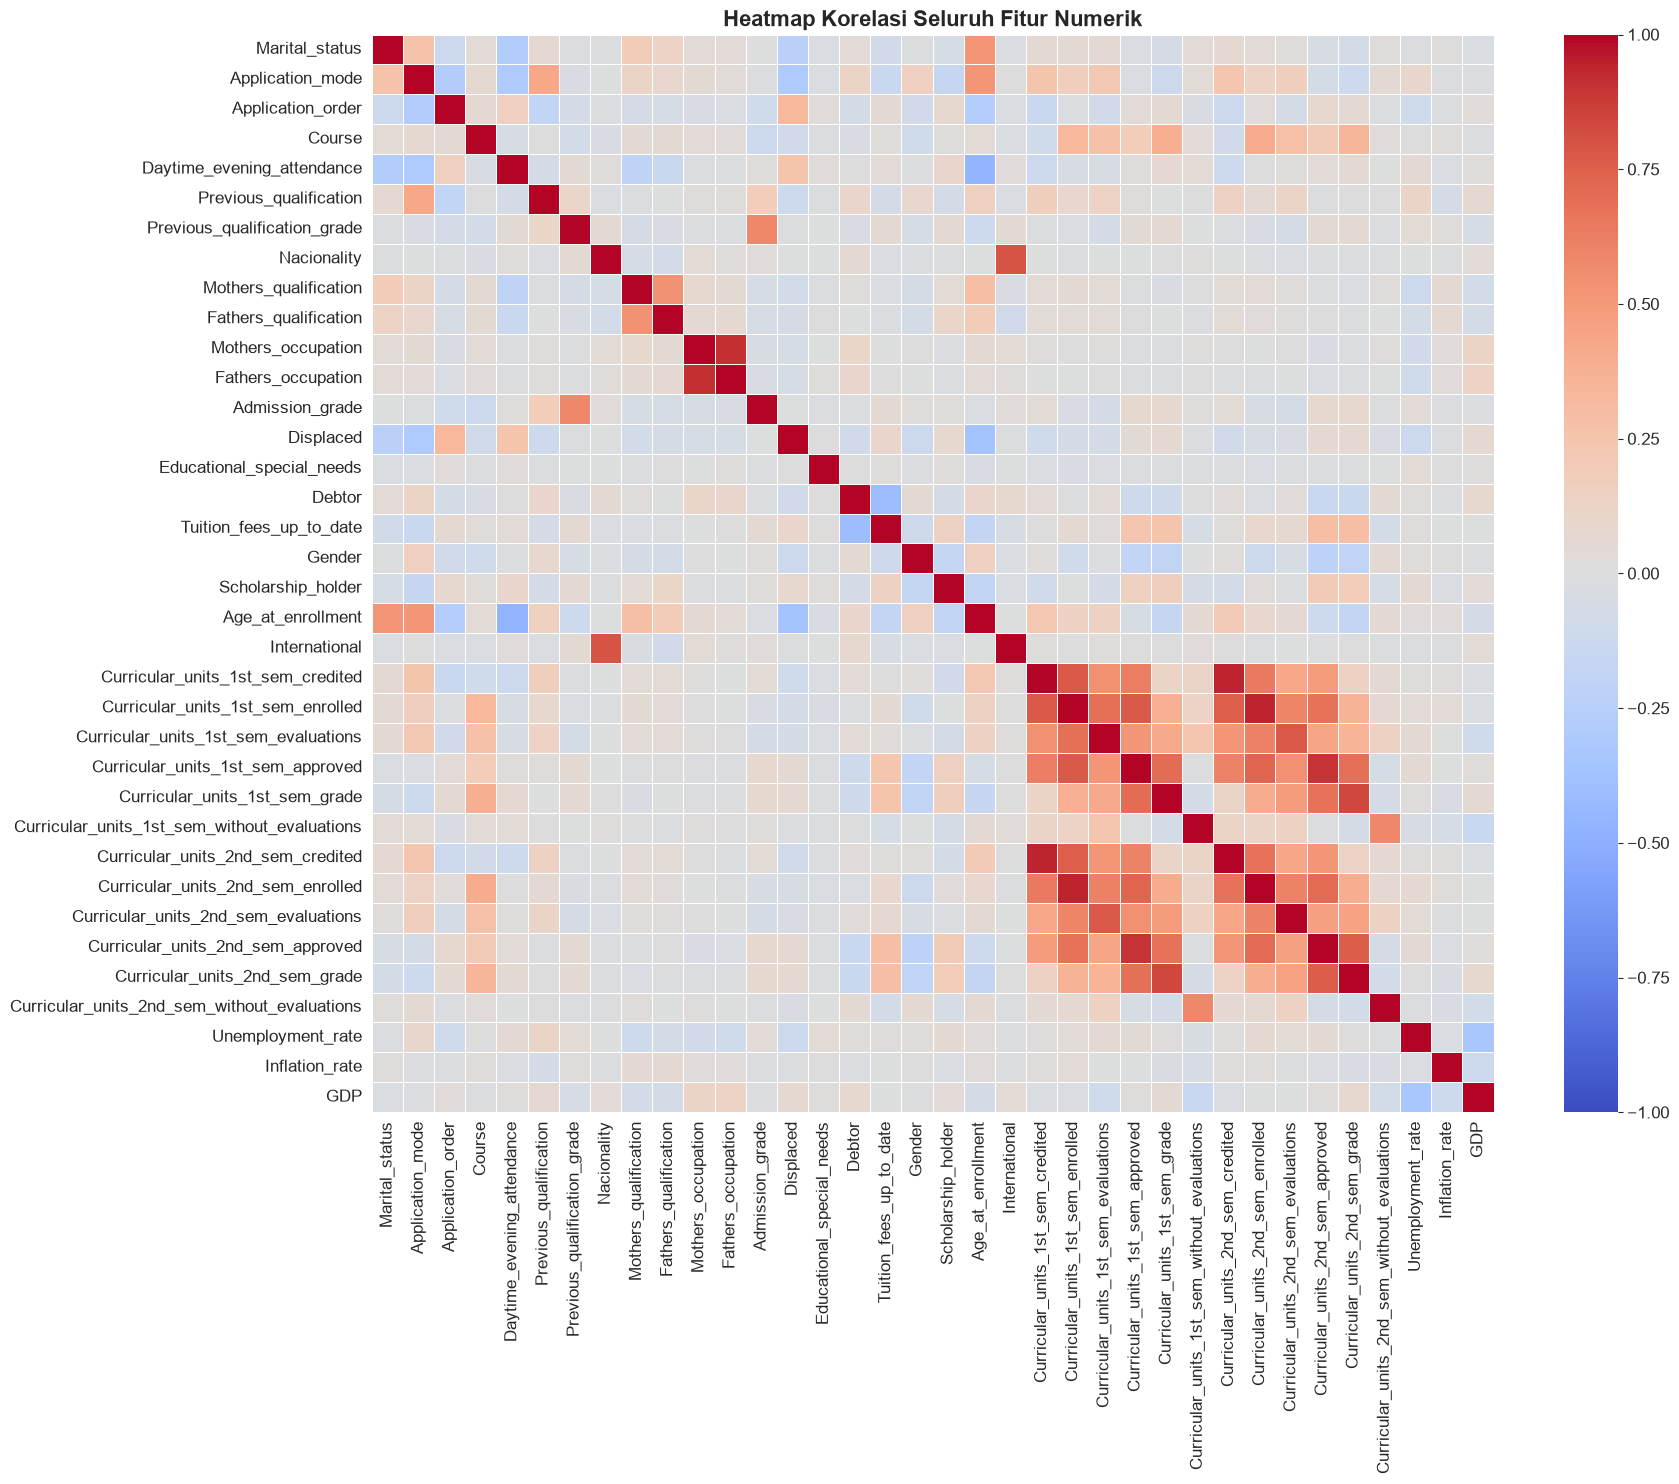

In [12]:
# Heatmap Korelasi Seluruh Fitur Numerik
# Filter data numerik saja untuk korelasi
numeric_df = df.select_dtypes(include=[np.number])
corr_matrix = numeric_df.corr()

plt.figure(figsize=(18, 15))
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', fmt='.2f', linewidths=0.5,
            vmin=-1, vmax=1)
plt.title('Heatmap Korelasi Seluruh Fitur Numerik', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

**Insight:** Heatmap korelasi menunjukkan beberapa pola penting:
- Terdapat korelasi kuat antara `Curricular_units_1st_sem_approved` dan `Curricular_units_1st_sem_grade` (mata kuliah lulus vs nilai rata-rata semester 1)
- Pola serupa terlihat di semester 2
- `Age_at_enrollment` berkorelasi negatif dengan beberapa fitur performa akademik
- Variabel makroekonomi (`Unemployment_rate`, `Inflation_rate`, `GDP`) memiliki korelasi lemah dengan fitur akademik

## Data Preparation / Preprocessing

Pada tahap preprocessing, dilakukan beberapa langkah penting:
1. **Filter data** — Hanya menggunakan mahasiswa dengan status `Dropout` dan `Graduate` (binary classification). Mahasiswa `Enrolled` di-drop karena status akhirnya belum diketahui.
2. **Encode target** — Dropout = 1, Graduate = 0
3. **Train-test split** — 80:20 dengan stratifikasi
4. **Feature scaling** — StandardScaler untuk fitur numerik
5. **SMOTE** — Menangani ketidakseimbangan kelas pada data training

In [13]:
# 1. Filter hanya Dropout dan Graduate (binary classification)
df_clean = df[df['Status'].isin(['Dropout', 'Graduate'])].copy()
print(f'Data setelah filter (hanya Dropout & Graduate): {df_clean.shape}')

# 2. Encode target: Dropout=1, Graduate=0
target_encoder = LabelEncoder()
df_clean['Status_encoded'] = target_encoder.fit_transform(df_clean['Status'])
print(f'Mapping target: {dict(zip(target_encoder.classes_, target_encoder.transform(target_encoder.classes_)))}')

# 3. Pisahkan fitur dan target
X = df_clean.drop(['Status', 'Status_encoded'], axis=1)
y = df_clean['Status_encoded']

print(f'\nJumlah fitur: {X.shape[1]}')
print(f'\nDistribusi target:')
print(y.value_counts())

Data setelah filter (hanya Dropout & Graduate): (3630, 37)
Mapping target: {'Dropout': np.int64(0), 'Graduate': np.int64(1)}

Jumlah fitur: 36

Distribusi target:
Status_encoded
1    2209
0    1421
Name: count, dtype: int64


In [14]:
# 4. Train-test split (80:20, stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Training set: {X_train.shape}')
print(f'Test set: {X_test.shape}')

# 5. Feature scaling
numerical_cols = X.select_dtypes(include=['number']).columns.tolist()

scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])
X_test_scaled[numerical_cols] = scaler.transform(X_test[numerical_cols])

# 6. SMOTE oversampling untuk menangani class imbalance
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train_scaled, y_train)

print(f'\nDistribusi kelas sebelum SMOTE: {dict(pd.Series(y_train).value_counts())}')
print(f'Distribusi kelas setelah SMOTE: {dict(pd.Series(y_train_res).value_counts())}')

Training set: (2904, 36)
Test set: (726, 36)

Distribusi kelas sebelum SMOTE: {1: np.int64(1767), 0: np.int64(1137)}
Distribusi kelas setelah SMOTE: {1: np.int64(1767), 0: np.int64(1767)}


## Modeling

Pada tahap ini, kita melatih model klasifikasi menggunakan algoritma **Gradient Boosting Classifier** yang dikenal handal untuk data tabular.

Model dikonfigurasi dengan parameter yang dioptimasi:
- `n_estimators=300` — Jumlah boosting stages
- `max_depth=5` — Kedalaman maksimum tree
- `learning_rate=0.05` — Learning rate rendah untuk generalisasi lebih baik
- `subsample=0.8` — Mengurangi overfitting dengan sampling

Setelah training, model dan seluruh preprocessor disimpan ke folder `model/` agar dapat digunakan pada prototype Streamlit.

In [15]:
# Gunakan Gradient Boosting Classifier
gb_model = GradientBoostingClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    min_samples_split=10,
    min_samples_leaf=5,
    subsample=0.8,
    random_state=42
)

print('Melatih model Gradient Boosting...')
gb_model.fit(X_train_res, y_train_res)
print('Training selesai!')

# Simpan model dan preprocessor ke folder model/
os.makedirs('model', exist_ok=True)
joblib.dump(gb_model, 'model/model.joblib')

preprocessor_data = {
    'scaler': scaler,
    'num_cols_to_scale': numerical_cols,
    'feature_columns': X.columns.tolist(),
    'target_encoder': target_encoder,
    'threshold': 0.35,
    'model_name': 'GradientBoosting'
}
joblib.dump(preprocessor_data, 'model/preprocessor.joblib')
print('Model dan preprocessor berhasil disimpan ke folder model/!')

Melatih model Gradient Boosting...
Training selesai!
Model dan preprocessor berhasil disimpan ke folder model/!


## Evaluation

Evaluasi model dilakukan menggunakan beberapa metrik:
- **Classification Report** — Precision, Recall, F1-Score per kelas
- **Confusion Matrix** — Visualisasi prediksi benar vs salah
- **ROC-AUC Score & Curve** — Mengukur kemampuan diskriminasi model
- **Feature Importance** — Mengetahui fitur paling berpengaruh

**Catatan:** Untuk kasus prediksi dropout, **Recall pada kelas Dropout** sangat penting. Kita ingin meminimalkan *false negative* (mahasiswa dropout yang diprediksi tidak dropout/graduate). Oleh karena itu, digunakan threshold kustom yang lebih rendah (0.35) agar lebih sensitif mendeteksi dropout.

In [16]:
# Evaluasi dengan threshold default (0.5) dan kustom
CUSTOM_THRESHOLD = 0.35

y_pred_proba = gb_model.predict_proba(X_test_scaled)[:, 1]
y_pred_default = (y_pred_proba >= 0.5).astype(int)
y_pred_custom = (y_pred_proba >= CUSTOM_THRESHOLD).astype(int)

# Classification Report
target_names = ['Graduate', 'Dropout']

print('=== Classification Report (Threshold = 0.5) ===')
print(classification_report(y_test, y_pred_default, target_names=target_names))

print(f'\n=== Classification Report (Threshold = {CUSTOM_THRESHOLD}) ===')
print(classification_report(y_test, y_pred_custom, target_names=target_names))

# ROC-AUC Score
roc_auc = roc_auc_score(y_test, y_pred_proba)
print(f'ROC-AUC Score: {roc_auc:.4f}')

=== Classification Report (Threshold = 0.5) ===
              precision    recall  f1-score   support

    Graduate       0.93      0.82      0.87       284
     Dropout       0.89      0.96      0.93       442

    accuracy                           0.91       726
   macro avg       0.91      0.89      0.90       726
weighted avg       0.91      0.91      0.91       726


=== Classification Report (Threshold = 0.35) ===
              precision    recall  f1-score   support

    Graduate       0.96      0.81      0.88       284
     Dropout       0.89      0.98      0.93       442

    accuracy                           0.91       726
   macro avg       0.92      0.89      0.90       726
weighted avg       0.92      0.91      0.91       726

ROC-AUC Score: 0.9544


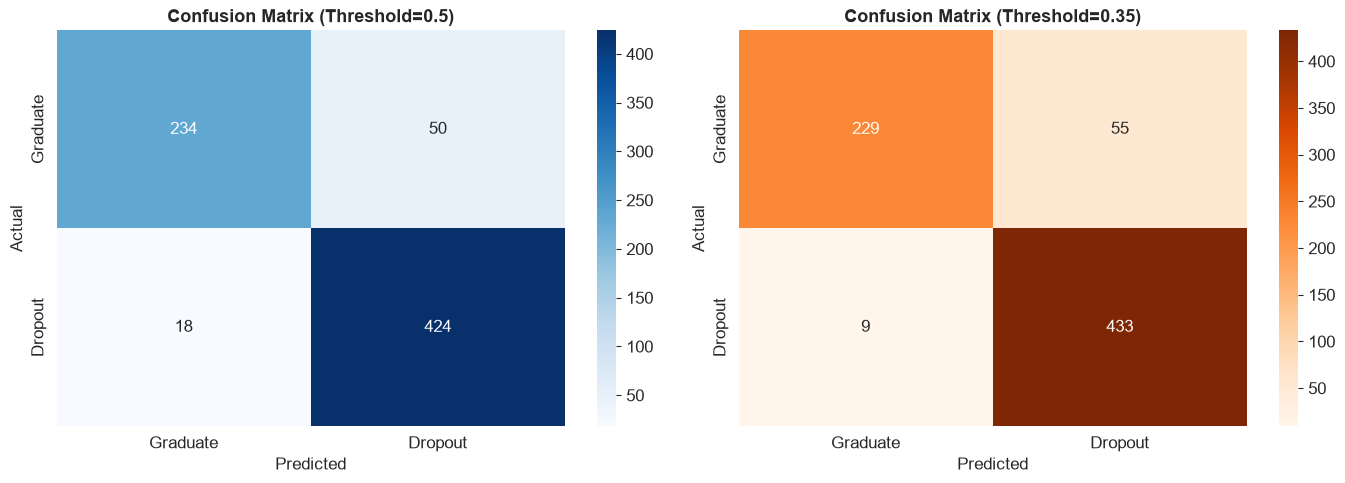

In [17]:
# Confusion Matrix Comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Default threshold
cm_default = confusion_matrix(y_test, y_pred_default)
sns.heatmap(cm_default, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=target_names, yticklabels=target_names)
axes[0].set_title('Confusion Matrix (Threshold=0.5)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

# Custom threshold
cm_custom = confusion_matrix(y_test, y_pred_custom)
sns.heatmap(cm_custom, annot=True, fmt='d', cmap='Oranges', ax=axes[1],
            xticklabels=target_names, yticklabels=target_names)
axes[1].set_title(f'Confusion Matrix (Threshold={CUSTOM_THRESHOLD})', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Actual')
axes[1].set_xlabel('Predicted')

plt.tight_layout()
plt.show()

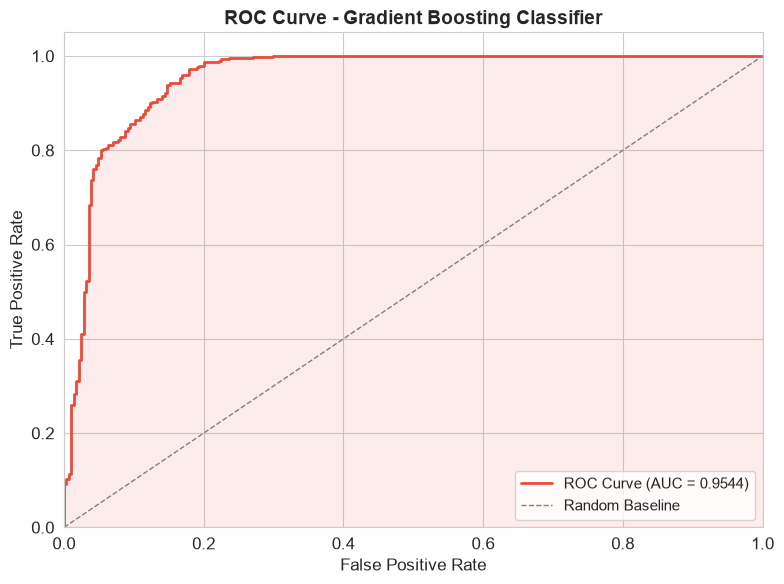

In [18]:
# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='#e74c3c', lw=2, label=f'ROC Curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--', label='Random Baseline')
plt.fill_between(fpr, tpr, alpha=0.1, color='#e74c3c')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve - Gradient Boosting Classifier', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=11)
plt.tight_layout()
plt.show()

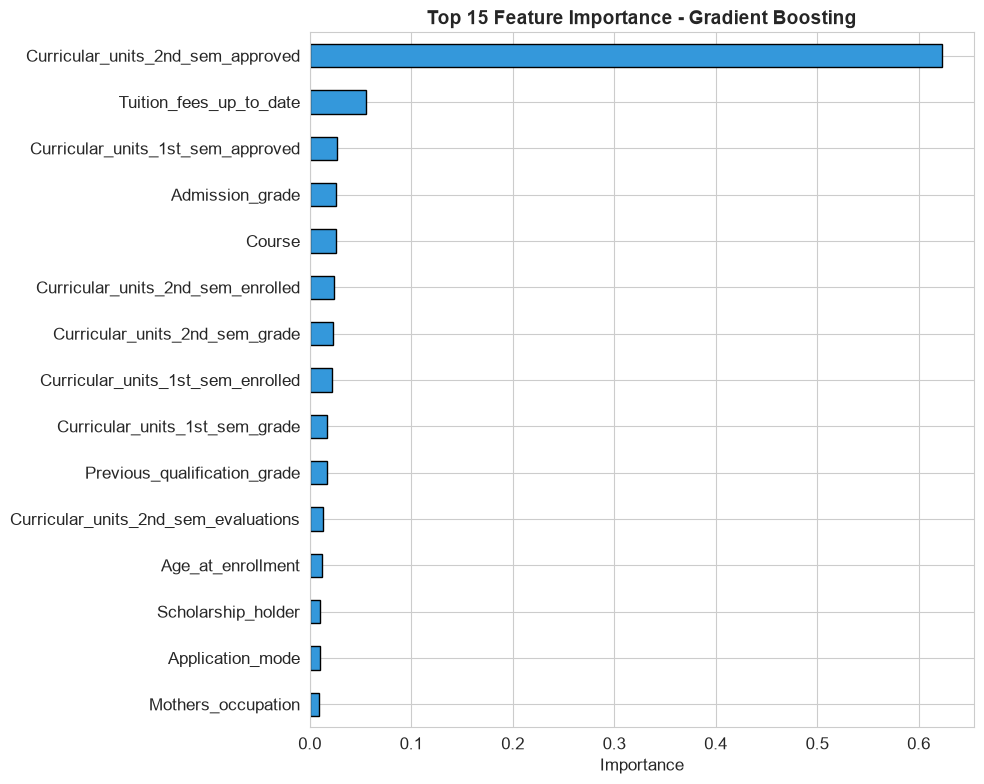


Top 10 Fitur Paling Penting:
  10. Previous_qualification_grade: 0.0171
  9. Curricular_units_1st_sem_grade: 0.0171
  8. Curricular_units_1st_sem_enrolled: 0.0223
  7. Curricular_units_2nd_sem_grade: 0.0232
  6. Curricular_units_2nd_sem_enrolled: 0.0244
  5. Course: 0.0258
  4. Admission_grade: 0.0263
  3. Curricular_units_1st_sem_approved: 0.0270
  2. Tuition_fees_up_to_date: 0.0558
  1. Curricular_units_2nd_sem_approved: 0.6234


In [19]:
# Feature Importance (Top 15)
feature_importance = pd.Series(
    gb_model.feature_importances_,
    index=X.columns
).sort_values(ascending=True)

top_15 = feature_importance.tail(15)

plt.figure(figsize=(10, 8))
top_15.plot(kind='barh', color='#3498db', edgecolor='black')
plt.title('Top 15 Feature Importance - Gradient Boosting', fontsize=14, fontweight='bold')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

print('\nTop 10 Fitur Paling Penting:')
for i, (feature, importance) in enumerate(feature_importance.tail(10).items(), 1):
    print(f'  {10-i+1}. {feature}: {importance:.4f}')

**Insight Evaluasi Model:**
- Model Gradient Boosting berhasil mencapai ROC-AUC yang baik, menunjukkan kemampuan diskriminasi yang kuat
- Dengan threshold kustom yang lebih rendah (0.35), Dropout Recall meningkat sehingga lebih banyak mahasiswa berisiko dropout berhasil terdeteksi
- Feature importance menunjukkan bahwa **performa akademik semester 1 dan 2** (nilai rata-rata dan jumlah mata kuliah lulus) merupakan prediktor terkuat
- Faktor **kelancaran pembayaran SPP** dan **usia saat pendaftaran** juga berperan signifikan